1. Imports

In [16]:
#import everything, get organized
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../app_old")

#import sklearn, our code, kernel ridge etc 
from kernel_ridge import KernelRidgeRegression, gaussian_kernel
from assessor import Assessment
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

#and finally import the data
df_full = pd.read_csv("../data/merged_final_transformed.csv")
print(f"Loaded: {df_full.shape}")

Loaded: (6646, 41)


2. Helper functions

In [ ]:
#prepare data for modeling
def prepare_data(df_full, target):
    other_targets = [t for t in ["CASTHMA","MHLTH","PHLTH","SLEEP","COPD","BPHIGH","STROKE"] if t != target]
    df = df_full.drop(columns=["County name","CountyFIPS"] + other_targets).dropna(subset=[target])
    cat_cols = df.select_dtypes(include=["object","category","str"]).columns.tolist()
    num_cols = [c for c in df.select_dtypes(include=["float64","int64"]).columns if c != target]
    return df.drop(columns=[target]), df[target], cat_cols, num_cols

#preprocess data for modeling
def preprocess(X_train, X_test, cat_cols, num_cols):
    ct = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", SimpleImputer(strategy="mean"), num_cols),
    ])
    X_tr = ct.fit_transform(X_train)
    X_te = ct.transform(X_test)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    return X_tr, X_te

assessor = Assessment()

3. Grid Search

In [ ]:
from sklearn.model_selection import KFold

#grid search using our KRR implementation
def cross_val_mse(model_params, X_tr, y_tr, n_splits=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mses = []
    for train_idx, val_idx in kf.split(X_tr):
        m = KernelRidgeRegression(**model_params)
        m.fit(X_tr[train_idx], y_tr[train_idx])
        preds = m.predict(X_tr[val_idx])
        mses.append(assessor.mean_squared_error(y_tr[val_idx], preds))
    return np.mean(mses)

lambs   = np.logspace(-6, -2, 6)
sigma2s = np.logspace(-2,  2, 6)

#tune hyperparameters for each target and store in BEST_PARAMS
BEST_PARAMS = {}

for target in ["CASTHMA", "MHLTH", "PHLTH", "SLEEP"]:
    X, y, cat_cols, num_cols = prepare_data(df_full, target)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_tr_np, X_te_np = preprocess(X_train, X_test, cat_cols, num_cols)
    y_tr_np = y_train.values

    best_mse, best_lamb, best_sigma2 = np.inf, None, None

    for lamb in lambs:
        for sigma2 in sigma2s:
            mse = cross_val_mse({"lamb": lamb, "sigma2": sigma2}, X_tr_np, y_tr_np)
            if mse < best_mse:
                best_mse    = mse
                best_lamb   = lamb
                best_sigma2 = sigma2

    BEST_PARAMS[target] = {"lamb": best_lamb, "sigma2": best_sigma2}
    print(f"{target:<10}  best lamb={best_lamb:.2e}  best sigma2={best_sigma2:.2e}  CV MSE={best_mse:.4f}")

print("\nBEST_PARAMS =", BEST_PARAMS)

CASTHMA     best lamb=1.00e-02  best sigma2=1.00e+02  CV MSE=2.8899
MHLTH       best lamb=1.58e-03  best sigma2=1.00e+02  CV MSE=8.6113
PHLTH       best lamb=1.00e-02  best sigma2=1.00e+02  CV MSE=7.9100
SLEEP       best lamb=2.51e-04  best sigma2=1.00e+02  CV MSE=218.1456

BEST_PARAMS = {'CASTHMA': {'lamb': np.float64(0.01), 'sigma2': np.float64(100.0)}, 'MHLTH': {'lamb': np.float64(0.001584893192461114), 'sigma2': np.float64(100.0)}, 'PHLTH': {'lamb': np.float64(0.01), 'sigma2': np.float64(100.0)}, 'SLEEP': {'lamb': np.float64(0.0002511886431509582), 'sigma2': np.float64(100.0)}}


4. Fit Models

In [ ]:
#print R2 and MSE on test set for each target using the best hyperparameters
results = {}
for target, params in BEST_PARAMS.items():
    X, y, cat_cols, num_cols = prepare_data(df_full, target)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_tr_np, X_te_np = preprocess(X_train, X_test, cat_cols, num_cols)
    y_tr_np, y_te_np = y_train.values, y_test.values

    model = KernelRidgeRegression(lamb=params["lamb"], sigma2=params["sigma2"])
    model.fit(X_tr_np, y_tr_np)

    y_pred, lower, upper = model.prediction_intervals(X_te_np, confidence=0.95)

    results[target] = {
        "y_test": y_te_np,
        "y_pred": y_pred,
        "lower":  lower,
        "upper":  upper,
        "r2":     assessor.r2_score(y_te_np, y_pred),
        "mse":    assessor.mean_squared_error(y_te_np, y_pred),
    }
    print(f"{target:<10}  R²={results[target]['r2']:.4f}  MSE={results[target]['mse']:.4f}")

CASTHMA     R²=0.2111  MSE=1.1929
MHLTH       R²=0.4569  MSE=4.1545
PHLTH       R²=0.2820  MSE=4.7254
SLEEP       R²=-0.4045  MSE=35.5483


5. Bar Chart Results

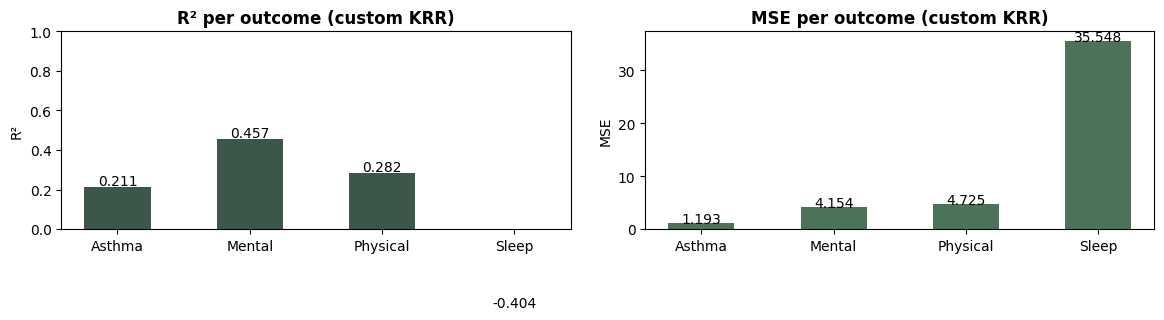

In [20]:

#plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#relabel for better visualization
labels = {
    "CASTHMA": "Asthma",
    "MHLTH":   "Mental",
    "PHLTH":   "Physical",
    "SLEEP":   "Sleep"
}
targets = list(results.keys())
short_labels = [labels.get(t, t) for t in targets]

r2s  = [results[t]["r2"]  for t in targets]
mses = [results[t]["mse"] for t in targets]

#design plot
ax1.bar(short_labels, r2s, color="#1a3a2a", alpha=0.85, width=0.5)
ax1.set_ylim(0, 1)
ax1.set_ylabel("R²")
ax1.set_title("R² per outcome (custom KRR)", fontweight="bold")
ax1.tick_params(axis="x", labelsize=10)
for i, v in enumerate(r2s):
    ax1.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

ax2.bar(short_labels, mses, color="#2d5a3d", alpha=0.85, width=0.5)
ax2.set_ylabel("MSE")
ax2.set_title("MSE per outcome (custom KRR)", fontweight="bold")
ax2.tick_params(axis="x", labelsize=10)
for i, v in enumerate(mses):
    ax2.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout(pad=2.0)
plt.savefig("diagnostics_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

6. Residuals Vs Predicted

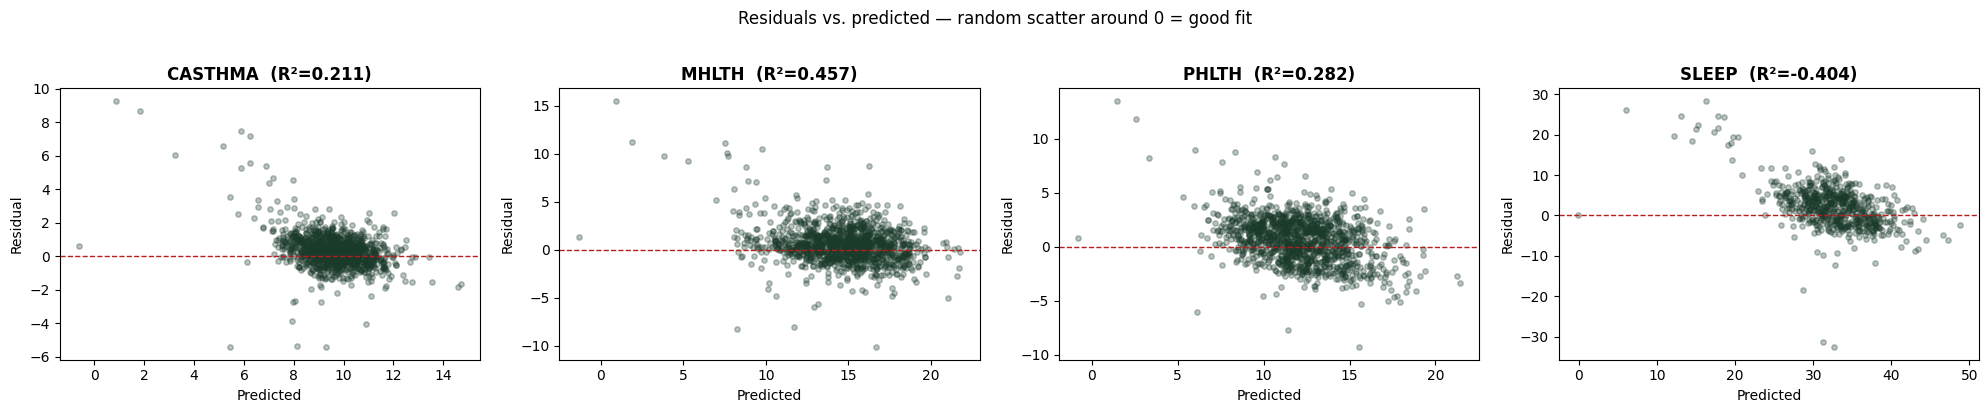

In [ ]:
#create resuiduals plot for each target
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

for ax, (target, r) in zip(axes, results.items()):
    residuals = r["y_test"] - r["y_pred"]
    ax.scatter(r["y_pred"], residuals, alpha=0.3, color="#1a3a2a", s=15)
    ax.axhline(0, color="#b91c1c", linewidth=1, linestyle="--")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(f"{target}  (R²={r['r2']:.3f})", fontweight="bold")

plt.suptitle("Residuals vs. predicted — random scatter around 0 = good fit", y=1.02)
plt.tight_layout()
plt.savefig("diagnostics_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

7. Predicted Vs Actual

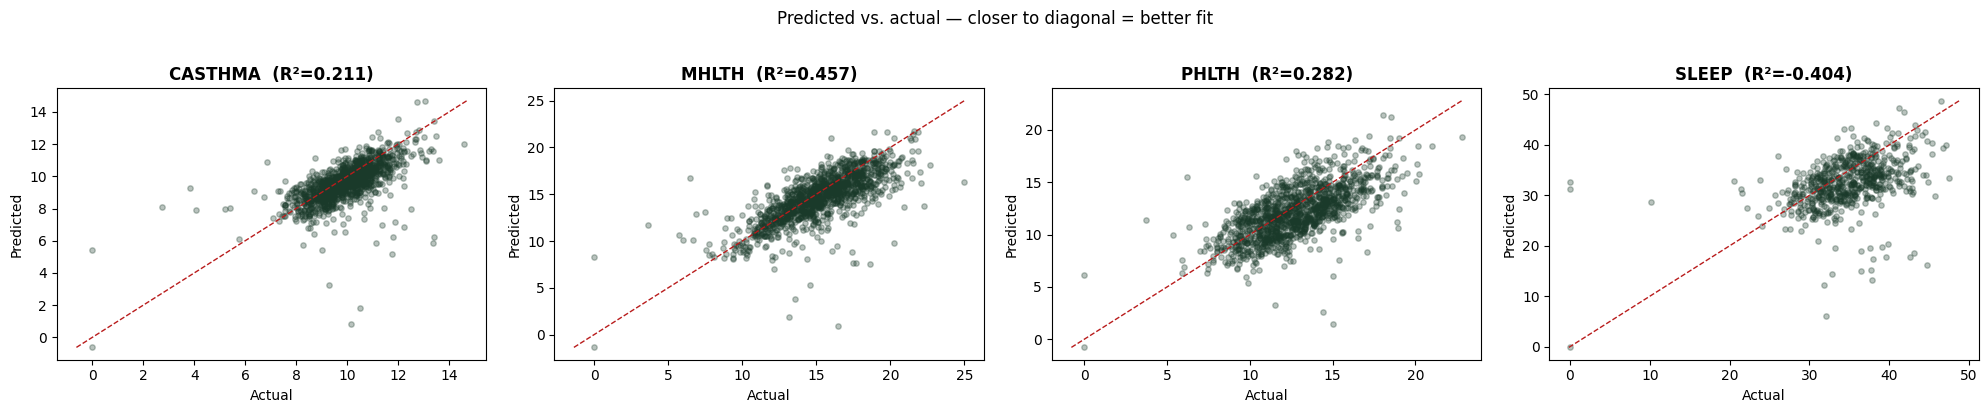

In [ ]:
#predicted vs actual plot for each target
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

for ax, (target, r) in zip(axes, results.items()):
    ax.scatter(r["y_test"], r["y_pred"], alpha=0.3, color="#1a3a2a", s=15)
    lo = min(r["y_test"].min(), r["y_pred"].min())
    hi = max(r["y_test"].max(), r["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], color="#b91c1c", linewidth=1, linestyle="--")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{target}  (R²={r['r2']:.3f})", fontweight="bold")

plt.suptitle("Predicted vs. actual — closer to diagonal = better fit", y=1.02)
plt.tight_layout()
plt.savefig("diagnostics_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

8. Prediction Intervals

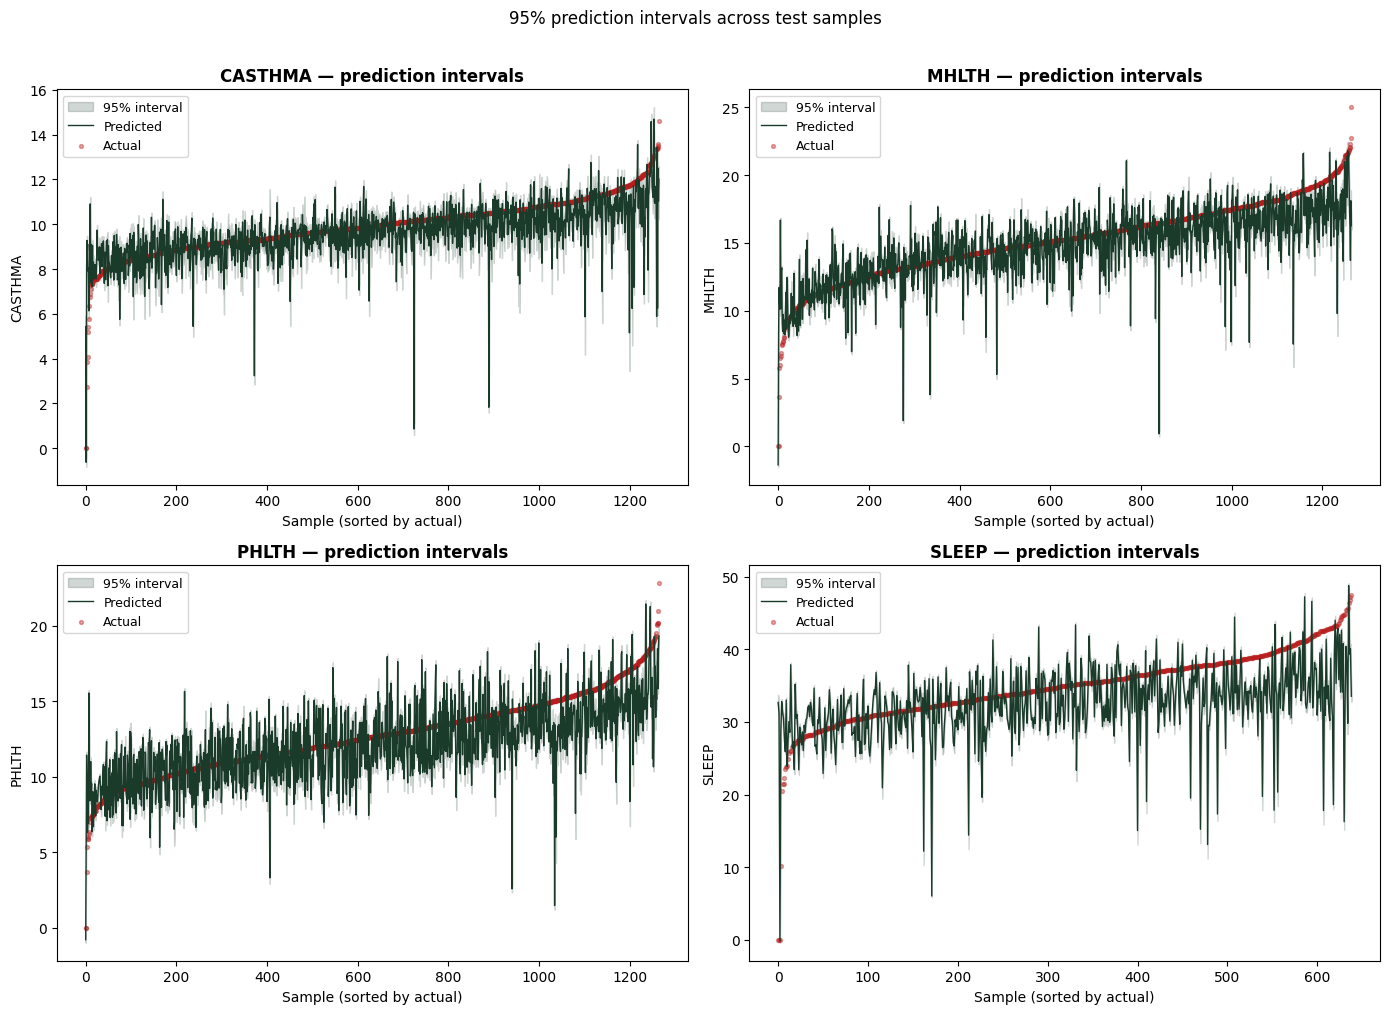

In [23]:
#sort by actual value for ribbon plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (target, r) in zip(axes, results.items()):
    sort_idx = np.argsort(r["y_test"])
    y_t = r["y_test"][sort_idx]
    y_p = r["y_pred"][sort_idx]
    lo  = r["lower"][sort_idx]
    hi  = r["upper"][sort_idx]
    #design plot
    ax.fill_between(range(len(y_t)), lo, hi, alpha=0.2, color="#1a3a2a", label="95% interval")
    ax.plot(y_p,  color="#1a3a2a", linewidth=1,   label="Predicted")
    ax.scatter(range(len(y_t)), y_t, color="#b91c1c", s=8, alpha=0.4, label="Actual")
    ax.set_xlabel("Sample (sorted by actual)")
    ax.set_ylabel(target)
    ax.set_title(f"{target} — prediction intervals", fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("95% prediction intervals across test samples", y=1.01)
plt.tight_layout()
plt.savefig("diagnostics_prediction_intervals.png", dpi=150, bbox_inches="tight")
plt.show()

9. Sigma Sweep

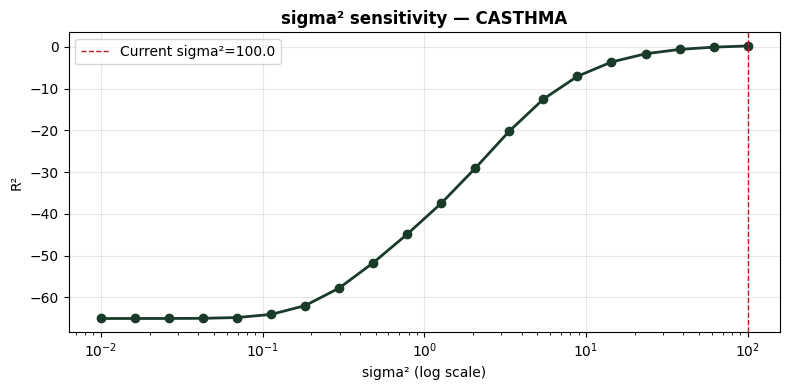

In [24]:
#sensitivity sweep for sigma2 on CASTHMA
target = "CASTHMA"
X, y, cat_cols, num_cols = prepare_data(df_full, target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_np, X_te_np = preprocess(X_train, X_test, cat_cols, num_cols)
y_tr_np, y_te_np = y_train.values, y_test.values

sigma2_values = np.logspace(-2, 2, 20)
r2_by_sigma2  = []

for s2 in sigma2_values:
    m = KernelRidgeRegression(lamb=BEST_PARAMS[target]["lamb"], sigma2=s2)
    m.fit(X_tr_np, y_tr_np)
    r2_by_sigma2.append(assessor.r2_score(y_te_np, m.predict(X_te_np)))

#plot sensitivity sweep

plt.figure(figsize=(8, 4))
plt.plot(sigma2_values, r2_by_sigma2, marker="o", color="#1a3a2a", linewidth=2)
plt.xscale("log")
plt.xlabel("sigma² (log scale)")
plt.ylabel("R²")
plt.title(f"sigma² sensitivity — {target}", fontweight="bold")
plt.axvline(BEST_PARAMS[target]["sigma2"], color="#b91c1c",
            linestyle="--", linewidth=1, label=f"Current sigma²={BEST_PARAMS[target]['sigma2']}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("diagnostics_sigma2_sweep.png", dpi=150, bbox_inches="tight")
plt.show()